In [50]:
from logistic_regression_baseline import *
from preprocessing import *
import csv
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Load train and test data

In [51]:
# Load train and test data
test_path = 'Data/ift-3395-6390-kaggle-2-competition-fall-2025/test_data.pkl'
train_path = 'Data/ift-3395-6390-kaggle-2-competition-fall-2025/train_data.pkl'

In [52]:
train_images, train_labels = get_train_images_labels(train_data)
test_images = get_test_images(test_data)

# Explore images and labels shape

In [53]:
print(f'Train images shape: {train_images.shape}, Train labels shape: {train_labels.shape}')

Train images shape: (1080, 28, 28, 3), Train labels shape: (1080, 1)


# Visualization of an example before preprocessing

Image example [[[ 6  4  0]
  [ 9  5  0]
  [ 8  4  0]
  ...
  [ 9  6  0]
  [ 9  6  0]
  [ 7  4  0]]

 [[11  6  0]
  [ 4  4  0]
  [ 3  3  0]
  ...
  [ 9  6  0]
  [ 6  4  0]
  [ 4  2  0]]

 [[11  6  0]
  [ 4  4  0]
  [ 3  3  0]
  ...
  [ 6  4  0]
  [ 6  4  0]
  [ 4  2  0]]

 ...

 [[ 1  1  0]
  [ 0  0  0]
  [ 0  0  1]
  ...
  [ 5  4  0]
  [ 6  5  0]
  [ 6  5  0]]

 [[ 3  1  1]
  [ 0  0  0]
  [ 0  0  1]
  ...
  [ 6  5  0]
  [ 6  5  0]
  [ 7  6  0]]

 [[10  2  2]
  [ 0  0  1]
  [ 0  0  1]
  ...
  [ 6  5  0]
  [ 7  6  0]
  [ 7  6  0]]]


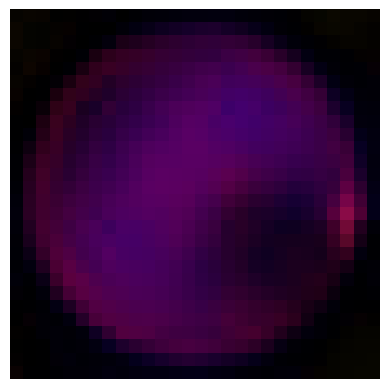

In [54]:
# Visualize an example
first_image = train_images[0]
print('Image example', first_image)
plt.imshow(first_image)
plt.axis("off")
plt.show()


# Visualization of an example after preprocessing

(array([[-0.3090653 , -0.14247105, -0.09978798, ...,  0.01564965,
         0.01086509,  0.00947791],
       [-0.10374415, -0.09966435, -0.01415355, ..., -0.19722293,
        -0.24703583, -0.24858235],
       [ 0.10157702,  0.0073523 ,  0.24274972, ..., -0.19722293,
        -0.24703583, -0.24858235],
       ...,
       [ 1.2103113 ,  0.1999823 , -0.3352827 , ..., -0.19722293,
        -0.16106887, -0.14105724],
       [-0.20640472, -0.14247105, -0.14260522, ..., -0.1546484 ,
        -0.20405234, -0.22707734],
       [-0.32959744, -0.335101  , -0.2710569 , ...,  0.01564965,
        -0.03211841, -0.01202711]], shape=(1080, 784), dtype=float32), array([0.03274873, 0.02700195, 0.02177924, 0.01639434, 0.01662552,
       0.01650933, 0.01568991, 0.01348463, 0.01200799, 0.01586781,
       0.02463689, 0.03220526, 0.04000363, 0.04548656, 0.04651413,
       0.04314692, 0.03391917, 0.02496854, 0.01802954, 0.01432826,
       0.01472283, 0.015748  , 0.0154539 , 0.01517187, 0.01882111,
       0.0198668

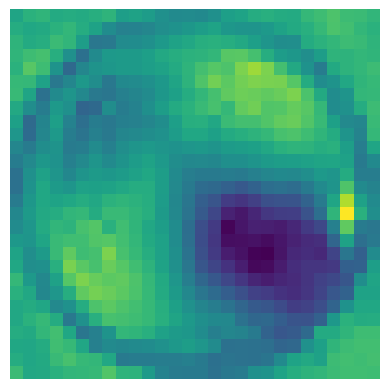

In [55]:
train_preprocessed_img = train_preprocessing(train_images)
print(train_preprocessed_img)
first_preprocessed_img = train_preprocessed_img[0][0]
plt.imshow(first_preprocessed_img.reshape(28,28))
plt.axis("off")
plt.show()


In [56]:
# Preprocess training data
X_train_norm, mean, std = train_preprocessing(train_images)
y_train = train_labels.flatten()

print("X_train_norm shape:", X_train_norm.shape)
print("y_train shape:", y_train.shape)

X_train_norm shape: (1080, 784)
y_train shape: (1080,)


## Visualization: Before and after preprocessing for each class

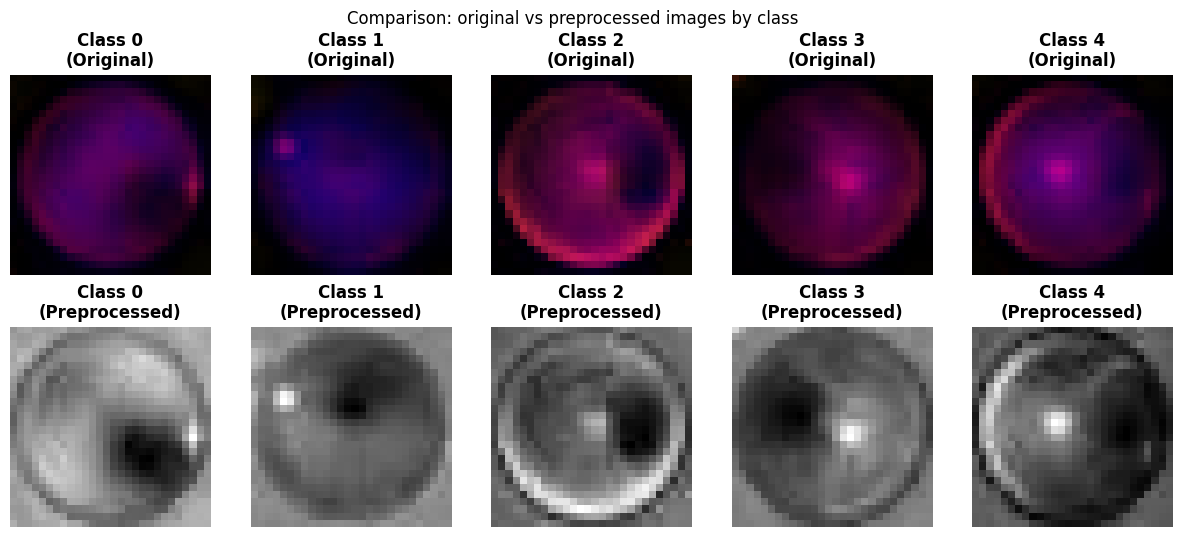

In [57]:
num_classes = 5
sample_indices = []
sample_images_original = []
sample_images_preprocessed = []

for class_label in range(num_classes):
    # Find first image of this class
    idx = np.where(train_labels == class_label)[0][0]
    sample_indices.append(idx)
    
    # Get original image
    original_img = train_images[idx]
    sample_images_original.append(original_img)
    
    # Get preprocessed image (reshape back to 28x28 for visualization)
    preprocessed_img = X_train_norm[idx].reshape(28, 28)
    sample_images_preprocessed.append(preprocessed_img)

fig, axes = plt.subplots(2, num_classes, figsize=(15, 6))

# First row: Original images
for i in range(num_classes):
    axes[0, i].imshow(sample_images_original[i], cmap='gray')
    axes[0, i].set_title(f'Class {i}\n(Original)', fontsize=12, fontweight='bold')
    axes[0, i].axis('off')

# Second row: Preprocessed images
for i in range(num_classes):
    axes[1, i].imshow(sample_images_preprocessed[i], cmap='gray')
    axes[1, i].set_title(f'Class {i}\n(Preprocessed)', fontsize=12, fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Comparison: original vs preprocessed images by class')
plt.show()


# Number of samples for each label

In [58]:
# Number of samples for each label 
dicc = {}
labels, counts = np.unique(train_labels, return_counts = True)
for label, count in zip(labels.astype(int), counts.astype(int)):  
    print(label,count) 


0 486
1 128
2 206
3 194
4 66


# Minimun and maximun value of pixels to normalize

In [59]:
print(f'Minimun value of pixels: {np.min(train_images)}')
print(f'Maximun value of píxels: {np.max(train_images)}')

Minimun value of pixels: 0
Maximun value of píxels: 255


# Baseline

# Logistic regression training

In [60]:
# Preprocess training data
X_train_norm, mean, std = train_preprocessing(train_images)
y_train = train_labels.flatten()

print("X_train_norm shape:", X_train_norm.shape)
print("y_train shape:", y_train.shape)

X_train_norm shape: (1080, 784)
y_train shape: (1080,)


In [61]:
# Train 5 models (one for each class) methodology one against the others
print("Training 5 models one vs rest...")
thetas, losses = train_ovr(
    X_train_norm,
    y_train,
    num_classes=5,
    alpha=0.001,
    num_iter=20000
)

print("thetas (weights) shape:", thetas.shape)


Training 5 models one vs rest...
thetas (weights) shape: (5, 785)


In [62]:
#Predictions in train
y_train_pred = predict_multiclass_ovr(X_train_norm, thetas)
accuracy = np.mean(y_train_pred == y_train)
print(f"Accuracy in training: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy in training: 0.5639 (56.39%)


# Logistic regression prediction

In [63]:
# Test preprocessing 
X_test_norm = preprocessing_test(test_images, mean, std)

# Test prediction
y_test_pred = predict_multiclass_ovr(X_test_norm, thetas)

print("X_test_norm shape:", X_test_norm.shape)
print("Predictions test shape:", y_test_pred.shape)

X_test_norm shape: (400, 784)
Predictions test shape: (400,)


In [49]:
def create_submission_csv(y_test_pred, filename):
    with open(filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["ID", "Label"])
        for i, label in enumerate(y_test_pred, start=1):
            writer.writerow([i, int(label)])

    print(f"File '{filename}' succesfully created.")

create_submission_csv(y_test_pred, "beating_the baseline_logistic_regression_model.csv")


File 'beating_the baseline_logistic_regression_model.csv' succesfully created.


## Hyperparameters details for beating the baseline
An accuracy of 0.495 was obtained in the public kaggle board with the following hyperparameters:

- Learning rate 0.001
- Number of iterations 20000


## Graphs

In [11]:
thetas, losses = train_ovr(X_train_norm, y_train, num_classes=5, alpha=0.001, num_iter=20000)

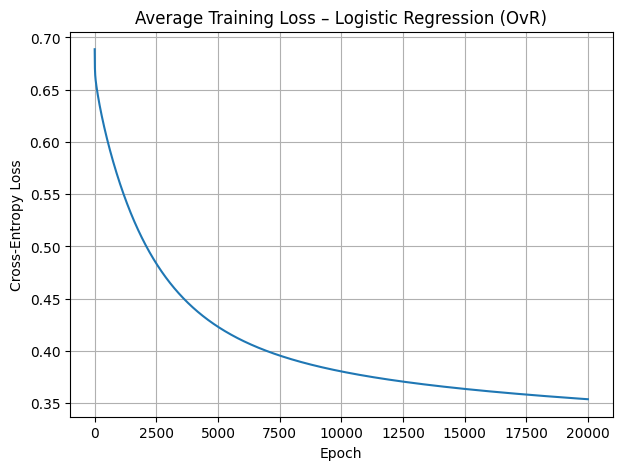

In [12]:
avg_loss = np.mean(np.array([np.array(l) for l in losses]), axis=0)

plt.figure(figsize=(7,5))
plt.plot(avg_loss)
plt.title("Average Training Loss – Logistic Regression (OvR)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()


In [16]:
thetas

array([[-0.24301974, -0.05409532, -0.00738077, ..., -0.0134534 ,
        -0.00732108, -0.0130664 ],
       [-1.98634743, -0.0703435 , -0.04202084, ..., -0.01995493,
        -0.01203217, -0.00925684],
       [-1.52263857,  0.05812175,  0.05362063, ...,  0.02191922,
         0.01642642,  0.01754588],
       [-1.63681783,  0.1256832 ,  0.00600609, ..., -0.00331033,
        -0.02186567, -0.02173677],
       [-2.42196391, -0.05604472, -0.00478045, ...,  0.02361899,
         0.03307753,  0.03553242]], shape=(5, 785))

In [22]:
print("Gradient norm for class 0: ")
print((np.linalg.norm(calculate_gradient(thetas[0], np.c_[np.ones((X_train_norm.shape[0],1)), X_train_norm], (y_train == 0).astype(int)))).round(4))
print("Gradient norm for class 1: ")
print((np.linalg.norm(calculate_gradient(thetas[1], np.c_[np.ones((X_train_norm.shape[0],1)), X_train_norm], (y_train == 1).astype(int)))).round(4))
print("Gradient norm for class 2: ")
print((np.linalg.norm(calculate_gradient(thetas[2], np.c_[np.ones((X_train_norm.shape[0],1)), X_train_norm], (y_train == 2).astype(int)))).round(4))
print("Gradient norm for class 3: ")
print((np.linalg.norm(calculate_gradient(thetas[3], np.c_[np.ones((X_train_norm.shape[0],1)), X_train_norm], (y_train == 3).astype(int)))).round(4))
print("Gradient norm for class 4: ")
print((np.linalg.norm(calculate_gradient(thetas[4], np.c_[np.ones((X_train_norm.shape[0],1)), X_train_norm], (y_train == 4).astype(int)))).round(4))


Gradient norm for class 0: 
0.0416
Gradient norm for class 1: 
0.0388
Gradient norm for class 2: 
0.0376
Gradient norm for class 3: 
0.0394
Gradient norm for class 4: 
0.0446


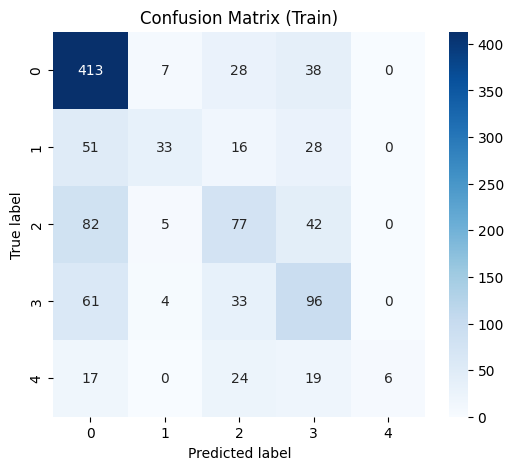

In [169]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = predict_multiclass_ovr(X_train_norm, thetas)
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Train)")
plt.show()

# Splitting data in training and validation

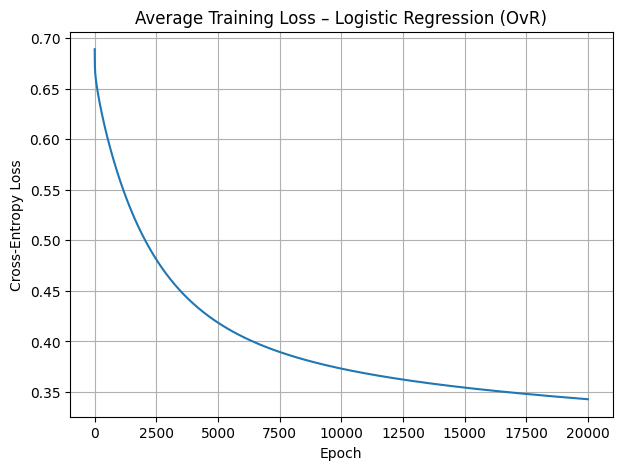

In [23]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train_norm, y_train, test_size=0.2, random_state=42)

# Clip extreme values to prevent numerical instability
X_tr = np.clip(X_tr, -10, 10)
X_val = np.clip(X_val, -10, 10)

thetas, losses = train_ovr(
    X_tr,
    y_tr,
    num_classes=5,
    alpha=0.001,
    num_iter=20000
)

avg_loss = np.mean(np.array([np.array(l) for l in losses]), axis=0)
plt.figure(figsize=(7,5))
plt.plot(avg_loss)
plt.title("Average Training Loss – Logistic Regression (OvR)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()


In [167]:
# Function to train OvR with validation loss tracking
def train_ovr_with_validation(X_train, y_train, X_val, y_val, num_classes=5, alpha=0.01, num_iter=2000):
    """
    Train One-vs-Rest logistic regression with validation loss tracking
    
    Returns:
    - thetas: trained weights for each class
    - train_losses: training loss history for each class
    - val_losses: validation loss history for each class
    """
    from log_reg_with_loss import sigmoid, compute_log_loss, calculate_gradient
    
    thetas = []
    train_losses = []
    val_losses = []
    
    # Add bias column to validation set
    X_val_b = np.c_[np.ones((X_val.shape[0], 1)), X_val]
    
    for k in range(num_classes):
        print(f"Training class {k}...")
        
        # Binary labels for this class
        y_train_k = (y_train == k).astype(int)
        y_val_k = (y_val == k).astype(int)
        
        # Add bias column to training set
        X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
        
        # Initialize weights
        theta = np.zeros(X_train_b.shape[1])
        
        train_loss_history = []
        val_loss_history = []
        
        # Gradient descent
        for i in range(num_iter):
            # Update weights
            grad = calculate_gradient(theta, X_train_b, y_train_k)
            theta -= alpha * grad
            
            # Calculate training loss
            train_loss = compute_log_loss(X_train_b, y_train_k, theta)
            train_loss_history.append(train_loss)
            
            # Calculate validation loss
            val_loss = compute_log_loss(X_val_b, y_val_k, theta)
            val_loss_history.append(val_loss)
        
        thetas.append(theta)
        train_losses.append(train_loss_history)
        val_losses.append(val_loss_history)
    
    return np.array(thetas), train_losses, val_losses



In [168]:
# Train with validation loss tracking
print("Training model with validation loss tracking...\n")

thetas_val, train_losses, val_losses = train_ovr_with_validation(
    X_tr, y_tr, 
    X_val, y_val,
    num_classes=5,
    alpha=0.001,
    num_iter=20000
)

print("\nTraining completed")

Training model with validation loss tracking...

Training class 0...
Training class 1...
Training class 2...
Training class 3...
Training class 4...

Training completed


In [106]:
avg_train_loss = np.mean(np.array([np.array(l) for l in train_losses]), axis=0)
avg_val_loss = np.mean(np.array([np.array(l) for l in val_losses]), axis=0)

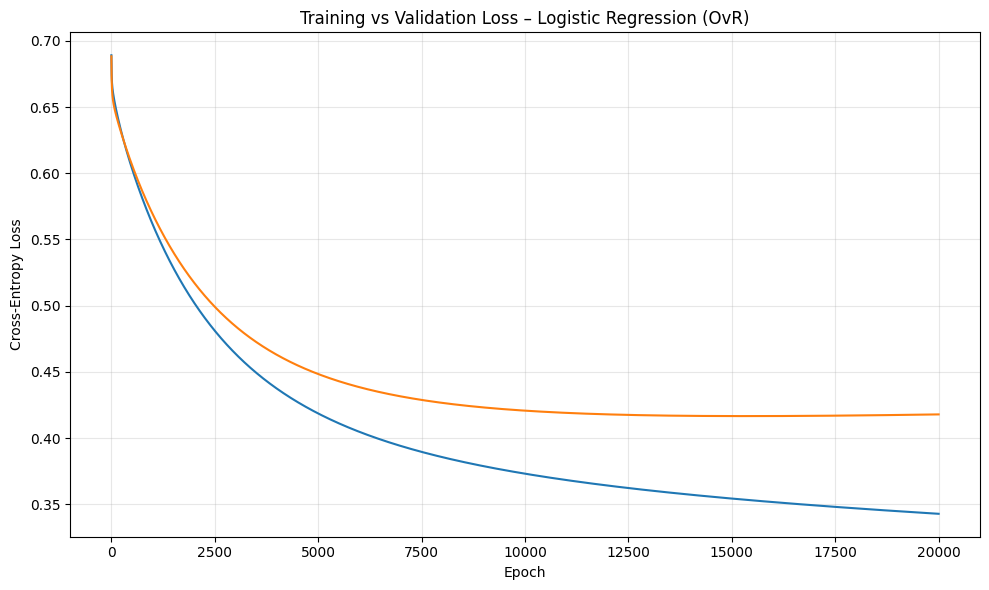

In [111]:
# Plot Training vs Validation Loss (comparison)
plt.figure(figsize=(10, 6))
plt.plot(avg_train_loss, label='Training Loss')
plt.plot(avg_val_loss, label='Validation Loss')
plt.title("Training vs Validation Loss – Logistic Regression (OvR)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Validation Accuracy: 0.5324074074074074


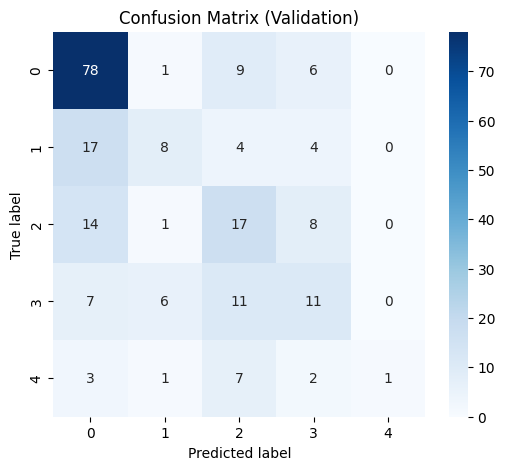

In [64]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns


y_val_pred = predict_multiclass_ovr(X_val, thetas)
val_acc = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_acc)

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Validation)")
plt.show()

In [65]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("Accuracy per class:", class_accuracy)

Accuracy per class: [0.82978723 0.24242424 0.425      0.31428571 0.07142857]


In [171]:
best_acc = 0
best_params = {}
results = []
alphas = [0.0005, 0.001, 0.005, 0.01]
num_iters = [10000, 20000, 30000]
for alpha in alphas:
    for num_iter in num_iters:
        print(f"Training with alpha={alpha}, num_iter={num_iter}")
        thetas, _ = train_ovr(X_tr, y_tr, num_classes=5, alpha=alpha, num_iter=num_iter)
        y_val_pred = predict_multiclass_ovr(X_val, thetas)
        acc = np.mean(y_val_pred == y_val)
        print(f"Validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
        results.append({'alpha': alpha, 'num_iter': num_iter, 'accuracy': acc})
        if acc > best_acc:
            best_acc = acc
            best_params = {'alpha': alpha, 'num_iter': num_iter}
print("Best combination:", best_params)
print("Best accuracy:", best_acc)

Training with alpha=0.0005, num_iter=10000
Validation accuracy: 0.4815 (48.15%)
Training with alpha=0.0005, num_iter=20000
Validation accuracy: 0.4583 (45.83%)
Training with alpha=0.0005, num_iter=30000
Validation accuracy: 0.4630 (46.30%)
Training with alpha=0.001, num_iter=10000
Validation accuracy: 0.4583 (45.83%)
Training with alpha=0.001, num_iter=20000
Validation accuracy: 0.4722 (47.22%)
Training with alpha=0.001, num_iter=30000
Validation accuracy: 0.4630 (46.30%)
Training with alpha=0.005, num_iter=10000
Validation accuracy: 0.4630 (46.30%)
Training with alpha=0.005, num_iter=20000
Validation accuracy: 0.4491 (44.91%)
Training with alpha=0.005, num_iter=30000
Validation accuracy: 0.4491 (44.91%)
Training with alpha=0.01, num_iter=10000
Validation accuracy: 0.4491 (44.91%)
Training with alpha=0.01, num_iter=20000
Validation accuracy: 0.4398 (43.98%)
Training with alpha=0.01, num_iter=30000
Validation accuracy: 0.4259 (42.59%)
Best combination: {'alpha': 0.0005, 'num_iter': 1000

# Data augmentation

In [38]:
# Data augmentation for minority classes (1, 2, 3, 4)
print("Original dataset size:", len(train_images))
print("Class distribution before augmentation:")
unique, counts = np.unique(train_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples")

# Create augmented dataset
train_images_aug = []
train_labels_aug = []

for img, label in zip(train_images, train_labels):
    train_images_aug.append(img)
    train_labels_aug.append(label)
    
    # Augment only minority classes (1, 2, 3, 4)
    if label != 0:
        # Horizontal flip
        train_images_aug.append(np.fliplr(img))
        train_labels_aug.append(label)
        
        # Vertical flip
        train_images_aug.append(np.flipud(img))
        train_labels_aug.append(label)
        
        # Rotation 90 degrees
        train_images_aug.append(np.rot90(img, k=1))
        train_labels_aug.append(label)
        
        # Rotation 180 degrees
        train_images_aug.append(np.rot90(img, k=2))
        train_labels_aug.append(label)

# Convert to numpy arrays
train_images_aug = np.array(train_images_aug)
train_labels_aug = np.array(train_labels_aug)

print("\nAugmented dataset size:", len(train_images_aug))
print("Class distribution after augmentation:")
unique, counts = np.unique(train_labels_aug, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples")

Original dataset size: 1080
Class distribution before augmentation:
  Class 0: 486 samples
  Class 1: 128 samples
  Class 2: 206 samples
  Class 3: 194 samples
  Class 4: 66 samples

Augmented dataset size: 3456
Class distribution after augmentation:
  Class 0: 486 samples
  Class 1: 640 samples
  Class 2: 1030 samples
  Class 3: 970 samples
  Class 4: 330 samples


In [39]:
# Preprocess augmented data
X_train_aug, mean_aug, std_aug = train_preprocessing(train_images_aug)
y_train_aug = train_labels_aug.flatten()

print("X_train_aug shape:", X_train_aug.shape)
print("y_train_aug shape:", y_train_aug.shape)

X_train_aug shape: (3456, 784)
y_train_aug shape: (3456,)


In [43]:
# Split augmented data into train and validation
X_tr_aug, X_val_aug, y_tr_aug, y_val_aug = train_test_split(
    X_train_aug, y_train_aug, test_size=0.2, random_state=42
)

print(f"Training set: {X_tr_aug.shape}")
print(f"Validation set: {X_val_aug.shape}")

Training set: (2764, 784)
Validation set: (692, 784)


In [44]:
# Grid search with augmented data
best_acc_aug = 0
best_params_aug = {}
results_aug = []
alphas = [0.0005, 0.001, 0.005, 0.01]
num_iters = [10000, 20000, 30000]

for alpha in alphas:
    for num_iter in num_iters:
        print(f"Training with alpha={alpha}, num_iter={num_iter}")
        thetas, _ = train_ovr(X_tr_aug, y_tr_aug, num_classes=5, alpha=alpha, num_iter=num_iter)
        y_val_pred_aug = predict_multiclass_ovr(X_val_aug, thetas)
        acc = np.mean(y_val_pred_aug == y_val_aug)
        print(f"Validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
        results_aug.append({'alpha': alpha, 'num_iter': num_iter, 'accuracy': acc})
        if acc > best_acc_aug:
            best_acc_aug = acc
            best_params_aug = {'alpha': alpha, 'num_iter': num_iter}

print("Best combination with augmented data:", best_params_aug)
print("Best validation accuracy:", best_acc_aug)

Training with alpha=0.0005, num_iter=10000
Validation accuracy: 0.4118 (41.18%)
Training with alpha=0.0005, num_iter=20000
Validation accuracy: 0.4220 (42.20%)
Training with alpha=0.0005, num_iter=30000
Validation accuracy: 0.4191 (41.91%)
Training with alpha=0.001, num_iter=10000
Validation accuracy: 0.4220 (42.20%)
Training with alpha=0.001, num_iter=20000
Validation accuracy: 0.4220 (42.20%)
Training with alpha=0.001, num_iter=30000
Validation accuracy: 0.4205 (42.05%)
Training with alpha=0.005, num_iter=10000
Validation accuracy: 0.4032 (40.32%)
Training with alpha=0.005, num_iter=20000
Validation accuracy: 0.3902 (39.02%)
Training with alpha=0.005, num_iter=30000
Validation accuracy: 0.3829 (38.29%)
Training with alpha=0.01, num_iter=10000
Validation accuracy: 0.3902 (39.02%)
Training with alpha=0.01, num_iter=20000
Validation accuracy: 0.3772 (37.72%)
Training with alpha=0.01, num_iter=30000
Validation accuracy: 0.3728 (37.28%)
Best combination with augmented data: {'alpha': 0.00

In [45]:
# Train with best hyperparameters on augmented data
print(f"Training with best params: alpha={best_params_aug['alpha']}, num_iter={best_params_aug['num_iter']}")
thetas_aug, _ = train_ovr(X_tr_aug, y_tr_aug, num_classes=5, 
                          alpha=best_params_aug['alpha'], 
                          num_iter=best_params_aug['num_iter'])

# Predictions on validation set
y_val_pred_aug = predict_multiclass_ovr(X_val_aug, thetas_aug)
val_acc_aug = accuracy_score(y_val_aug, y_val_pred_aug)
print(f"Validation Accuracy (augmented): {val_acc_aug:.4f} ({val_acc_aug*100:.2f}%)")


Training with best params: alpha=0.0005, num_iter=20000
Validation Accuracy (augmented): 0.4220 (42.20%)


In [47]:
import seaborn as sns

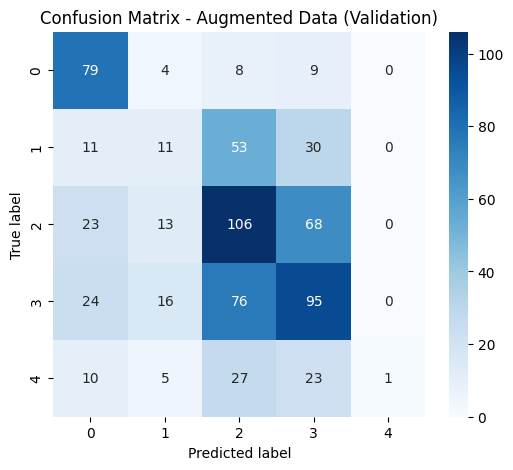


Accuracy per class (augmented):
  Class 0: 0.7900 (79.00%)
  Class 1: 0.1048 (10.48%)
  Class 2: 0.5048 (50.48%)
  Class 3: 0.4502 (45.02%)
  Class 4: 0.0152 (1.52%)


In [48]:
# Confusion matrix
cm_aug = confusion_matrix(y_val_aug, y_val_pred_aug)
plt.figure(figsize=(6,5))
sns.heatmap(cm_aug, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Augmented Data (Validation)")
plt.show()

class_accuracy_aug = cm_aug.diagonal() / cm_aug.sum(axis=1)
print("\nAccuracy per class (augmented):")
for i, acc in enumerate(class_accuracy_aug):
    print(f"  Class {i}: {acc:.4f} ({acc*100:.2f}%)")

In [52]:
# Train final model with ALL augmented data and create submission
print(f"Training final model with alpha={best_params_aug['alpha']}, num_iter={best_params_aug['num_iter']} on all augmented data...")
thetas_final_aug, _ = train_ovr(X_train_aug, y_train_aug, num_classes=5, 
                                 alpha=best_params_aug['alpha'], 
                                 num_iter=best_params_aug['num_iter'])

# Preprocess test data with augmented mean/std
X_test_aug = preprocessing_test(test_images, mean_aug, std_aug)

# Predictions on test set
y_test_pred_aug = predict_multiclass_ovr(X_test_aug, thetas_final_aug)

# Create submission file
create_submission_csv(y_test_pred_aug, "submission_logreg_augmented.csv")

print(f"\nModel trained with {len(train_images_aug)} samples (augmented)")
print("Submission file created: submission_logreg_augmented.csv")

Training final model with alpha=0.0005, num_iter=20000 on all augmented data...
File 'submission_logreg_augmented.csv' succesfully created.

Model trained with 3456 samples (augmented)
Submission file created: submission_logreg_augmented.csv
File 'submission_logreg_augmented.csv' succesfully created.

Model trained with 3456 samples (augmented)
Submission file created: submission_logreg_augmented.csv


# Alternative strategies to improve model

Since data augmentation didn't improve results significantly, let's try:
1. PCA for dimensionality reduction
2. Class weighting to handle imbalance
3. Other models


## Strategy 1: PCA for dimensionality reduction

In [174]:
from sklearn.decomposition import PCA

# Try different numbers of components
n_components_list = [100, 200, 300, 400]
pca_results = []

for n_comp in n_components_list:
    print(f"\nTesting with {n_comp} PCA components...")
    
    # Apply PCA
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_norm)
    
    # Split into train/val
    X_tr_pca, X_val_pca, y_tr_pca, y_val_pca = train_test_split(
        X_train_pca, y_train, test_size=0.2, random_state=42
    )
    
    # Train with best hyperparameters from before
    thetas_pca, _ = train_ovr(X_tr_pca, y_tr_pca, num_classes=5, 
                              alpha=0.001, num_iter=20000)
    
    # Evaluate
    y_val_pred_pca = predict_multiclass_ovr(X_val_pca, thetas_pca)
    acc_pca = np.mean(y_val_pred_pca == y_val_pca)
    
    print(f"  Validation accuracy: {acc_pca:.4f} ({acc_pca*100:.2f}%)")
    print(f"  Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")
    
    pca_results.append({
        'n_components': n_comp,
        'accuracy': acc_pca,
        'explained_variance': pca.explained_variance_ratio_.sum()
    })

# Find best
best_pca = max(pca_results, key=lambda x: x['accuracy'])
print(f"Best PCA configuration: {best_pca['n_components']} components")
print(f"Best accuracy: {best_pca['accuracy']:.4f}")


Testing with 100 PCA components...
  Validation accuracy: 0.4630 (46.30%)
  Explained variance ratio: 0.9941

Testing with 200 PCA components...
  Validation accuracy: 0.4630 (46.30%)
  Explained variance ratio: 0.9980

Testing with 300 PCA components...
  Validation accuracy: 0.4722 (47.22%)
  Explained variance ratio: 0.9994

Testing with 400 PCA components...
  Validation accuracy: 0.4722 (47.22%)
  Explained variance ratio: 0.9999
Best PCA configuration: 300 components
Best accuracy: 0.4722


## Strategy 2: Class weighting to handle imbalance

In [175]:
from sklearn.linear_model import LogisticRegression

# Test different solvers and penalties
configs = [
    {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0},
    {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1},
    {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10.0},
]

balanced_results = []

for config in configs:
    print(f"\nTesting: {config}")
    
    clf = LogisticRegression(
        max_iter=5000,
        class_weight='balanced',  
        random_state=42,
        **config
    )
    
    clf.fit(X_tr, y_tr)
    y_val_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    
    print(f"Validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Per-class accuracy
    cm = confusion_matrix(y_val, y_val_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"  Class accuracies: {class_acc.round(3)}")
    
    balanced_results.append({'config': config, 'accuracy': acc})

best_balanced = max(balanced_results, key=lambda x: x['accuracy'])
print(f"Best config: {best_balanced['config']}")
print(f"Best accuracy: {best_balanced['accuracy']:.4f}")


Testing: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}
Validation accuracy: 0.4306 (43.06%)
  Class accuracies: [0.66  0.333 0.325 0.114 0.214]

Testing: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
Validation accuracy: 0.4306 (43.06%)
  Class accuracies: [0.681 0.364 0.275 0.086 0.214]

Testing: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10.0}
Validation accuracy: 0.4306 (43.06%)
  Class accuracies: [0.66  0.333 0.275 0.171 0.214]
Best config: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}
Best accuracy: 0.4306


## Strategy 3: Try other models 

In [176]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Compare multiple models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

model_results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_tr, y_tr)
    
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    
    print(f"  Validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"  Per-class accuracy: {class_acc.round(3)}")
    
    model_results.append({'model': name, 'accuracy': acc, 'classifier': model})

# Best model
best_model_result = max(model_results, key=lambda x: x['accuracy'])
print(f"Best model: {best_model_result['model']}")
print(f"Best accuracy: {best_model_result['accuracy']:.4f}")


Training Random Forest...
  Validation accuracy: 0.5231 (52.31%)
  Per-class accuracy: [0.872 0.152 0.275 0.4   0.071]

Training Gradient Boosting...
  Validation accuracy: 0.4537 (45.37%)
  Per-class accuracy: [0.809 0.121 0.2   0.2   0.214]

Training SVM (RBF)...
  Validation accuracy: 0.4954 (49.54%)
  Per-class accuracy: [0.766 0.303 0.2   0.171 0.786]

Training K-Nearest Neighbors...
  Validation accuracy: 0.4722 (47.22%)
  Per-class accuracy: [0.809 0.121 0.35  0.229 0.   ]
Best model: Random Forest
Best accuracy: 0.5231


### Create submission with best model (Random Forest)

In [57]:
# Train Random Forest on ALL training data with best configuration found in validation
print("Training Random Forest on full training set...")

rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  
)

# Train on all training data
rf_final.fit(X_train_norm, y_train)

# Check training accuracy
y_train_pred_rf = rf_final.predict(X_train_norm)
train_acc_rf = np.mean(y_train_pred_rf == y_train)
print(f"Training accuracy: {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")

# Make predictions on test set
y_test_pred_rf = rf_final.predict(X_test_norm)

# Create submission file
create_submission_csv(y_test_pred_rf, "submission_random_forest.csv")

print("\nRandom Forest model trained and submission created!")
print("File: submission_random_forest.csv")

Training Random Forest on full training set...
Training accuracy: 1.0000 (100.00%)
File 'submission_random_forest.csv' succesfully created.

Random Forest model trained and submission created!
File: submission_random_forest.csv


# Tune Random Forest hyperparameters

In [177]:
# Try different Random Forest configurations
print("Tuning Random Forest hyperparameters...\n")

rf_configs = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5},
    {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 3},
]

rf_tuning_results = []

for config in rf_configs:
    print(f"Testing: {config}")
    
    rf = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_split=config['min_samples_split'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_tr, y_tr)
    y_val_pred_rf = rf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred_rf)
    
    print(f"  Validation accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Per-class accuracy
    cm = confusion_matrix(y_val, y_val_pred_rf)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"  Per-class accuracy: {class_acc.round(3)}\n")
    
    rf_tuning_results.append({'config': config, 'accuracy': acc, 'model': rf})

# Best configuration
best_rf_config = max(rf_tuning_results, key=lambda x: x['accuracy'])
print(f"Best Random Forest config: {best_rf_config['config']}")
print(f"Best validation accuracy: {best_rf_config['accuracy']:.4f}")

Tuning Random Forest hyperparameters...

Testing: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
  Validation accuracy: 0.5231 (52.31%)
  Per-class accuracy: [0.872 0.152 0.275 0.4   0.071]

Testing: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
  Validation accuracy: 0.5278 (52.78%)
  Per-class accuracy: [0.872 0.152 0.25  0.429 0.143]

Testing: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5}
  Validation accuracy: 0.5231 (52.31%)
  Per-class accuracy: [0.819 0.182 0.325 0.457 0.071]

Testing: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5}
  Validation accuracy: 0.5093 (50.93%)
  Per-class accuracy: [0.819 0.212 0.25  0.429 0.071]

Testing: {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 3}
  Validation accuracy: 0.5139 (51.39%)
  Per-class accuracy: [0.851 0.242 0.2   0.4   0.071]

Best Random Forest config: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
Best validation accuracy: 0.5278


In [59]:
# Train final model with best RF configuration and create submission
print(f"Training final Random Forest with best config: {best_rf_config['config']}")

rf_best = RandomForestClassifier(
    n_estimators=best_rf_config['config']['n_estimators'],
    max_depth=best_rf_config['config']['max_depth'],
    min_samples_split=best_rf_config['config']['min_samples_split'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train on ALL training data
rf_best.fit(X_train_norm, y_train)

# Training accuracy
y_train_pred_rf_best = rf_best.predict(X_train_norm)
train_acc_rf_best = np.mean(y_train_pred_rf_best == y_train)
print(f"Training accuracy: {train_acc_rf_best:.4f} ({train_acc_rf_best*100:.2f}%)")

# Predictions on test
y_test_pred_rf_best = rf_best.predict(X_test_norm)

# Create submission
create_submission_csv(y_test_pred_rf_best, "submission_random_forest_tuned.csv")

print("\nTuned Random Forest submission created")
print("File: submission_random_forest_tuned.csv")

Training final Random Forest with best config: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
Training accuracy: 1.0000 (100.00%)
File 'submission_random_forest_tuned.csv' succesfully created.

Tuned Random Forest submission created!
File: submission_random_forest_tuned.csv
